# Hierarchical Clustering Tutorial

**By Rebe**

Welcome! This notebook teaches hierarchical clustering - a different approach to grouping similar data without knowing labels beforehand.

### 🛠️ Setup: Installing & Importing Libraries

We need libraries for:
- `ISLP`: NCI60 dataset
- `scikit-learn`: StandardScaler for preprocessing
- `scipy.cluster.hierarchy`: Hierarchical clustering & dendrograms
- `matplotlib`: Plotting dendrograms

In [2]:
pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a5ab1c55428bd5ca5f4deeeb533f1cb3604eaa1e617629b744facf0a66dc9428
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
from ISLP import load_data

## Step 1: Load the Data

We'll use the same NCI60 dataset. This time we'll cluster using hierarchical methods instead of K-Means.

In [4]:
nci60_data = load_data('NCI60')
print('Labels head:')
display(nci60_data['labels'].head())
print('\nData array (first 5 rows):')
display(nci60_data['data'][:5])

Labels head:


,label
0,CNS
1,CNS
2,CNS
3,RENAL
4,BREAST



Data array (first 5 rows):


array([[ 0.3     ,  1.18    ,  0.55    , ...,  0.28    , -0.34    ,
        -1.93    ],
       [ 0.679961,  1.289961,  0.169961, ..., -0.770039, -0.390039,
        -2.000039],
       [ 0.94    , -0.04    , -0.17    , ..., -0.12    , -0.41    ,
         0.      ],
       [ 0.28    , -0.31    ,  0.68    , ...,  1.09    , -0.26    ,
        -1.1     ],
       [ 0.485   , -0.465   ,  0.395   , ...,  0.745   ,  0.425   ,
         0.145   ]])

## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a popular technique for dimensionality reduction. It transforms a dataset into a new set of orthogonal variables called principal components, which capture the maximum variance in the data. Before applying PCA, it's often good practice to scale the data to ensure that features with larger values do not dominate the analysis.

Here, I will:
1. Import necessary libraries: `PCA` from `sklearn.decomposition` and `StandardScaler` from `sklearn.preprocessing`.
2. Standardize the `data` array from `nci60_data`.
3. Apply PCA to the scaled data to reduce its dimensionality.

## Understanding Hierarchical Clustering

Unlike K-Means, hierarchical clustering builds a tree of clusters (dendrogram). You decide how many clusters by cutting the tree.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

In [6]:
# Extract the data array
X = nci60_data['data']

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print('Original data shape:', X.shape)
print('Transformed data shape:', X_pca.shape)

# Display the first 5 rows of the PCA transformed data
print('\nFirst 5 rows of PCA transformed data:')
display(X_pca[:5])

Original data shape: (64, 6830)
Transformed data shape: (64, 64)

First 5 rows of PCA transformed data:


array([[ 1.98380417e+01, -3.55563601e+00, -9.81239940e+00,
        -8.24246367e-01, -1.26099840e+01,  7.47150463e+00,
         1.41907304e+01,  3.19797687e+00, -2.19383501e+01,
        -2.03693629e+01,  1.24456588e+01, -2.02894856e+01,
        -6.53152187e+00,  3.61900794e+00,  3.79551696e+00,
         6.17552795e+00,  2.03234329e+01,  8.84184247e+00,
         6.86795443e+00,  5.97442117e+00, -7.29737133e+00,
         7.62653453e+00,  1.15798655e+01,  1.45170647e+01,
        -7.31502403e+00, -3.47136520e+00,  1.10586500e+01,
         1.18822992e+00,  6.80937888e-01, -3.11818202e+00,
        -4.59460500e+00,  1.73316998e+00, -4.36299389e+00,
         2.32835227e+00,  6.95951505e-01, -7.93525900e+00,
         5.78384606e-01, -5.10159649e+00, -2.34550272e+00,
        -1.49356076e+01, -3.61961984e+00, -7.18180703e+00,
        -5.00458627e+00,  3.55672726e+00,  5.03860513e+00,
         6.65707994e-03,  5.84540388e+00,  2.10459480e+00,
         1.52275298e+01, -1.10438285e+01,  9.93370511e+0

### 🌳 Preparing for Hierarchical Clustering

`StandardScaler` normalizes features to mean=0, std=1. Then we use `linkage()` with 'complete' method:
- **Complete linkage**: Distance = farthest points between clusters
- This tends to create balanced, compact clusters

## Step 2: Prepare the Data

Again, standardization is key. All features need equal weight in distance calculations.

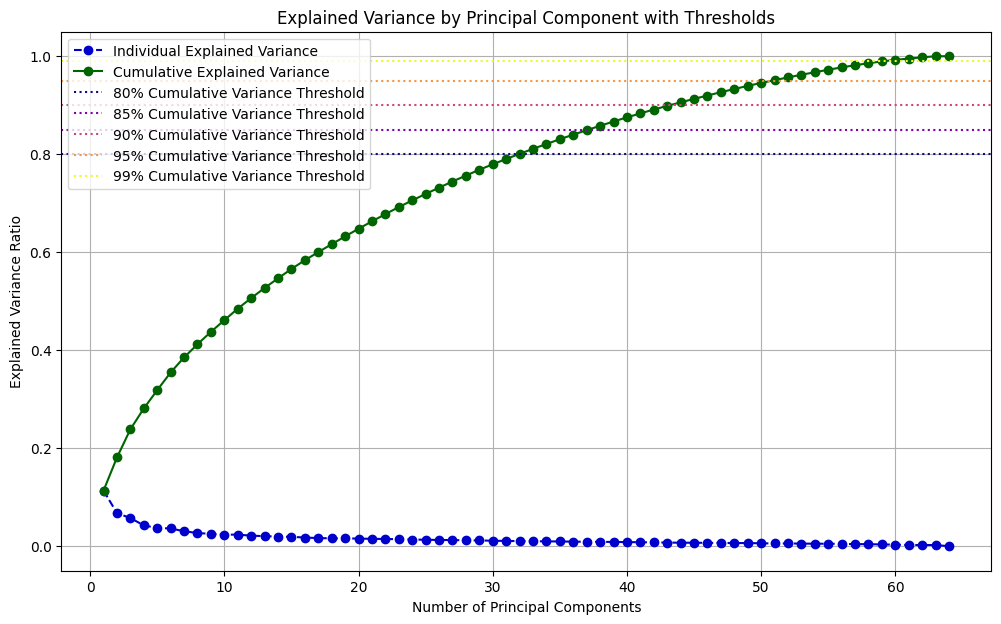

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Create a plot
plt.figure(figsize=(12, 7))

# Plot individual and cumulative explained variance with different colors
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='mediumblue', label='Individual Explained Variance')
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='darkgreen', label='Cumulative Explained Variance')

# Add threshold lines with a color palette
thresholds = [0.80, 0.85, 0.90, 0.95, 0.99] # Removed 0.92
colors = plt.colormaps.get_cmap('plasma')

for i, threshold in enumerate(thresholds):
    plt.axhline(y=threshold, color=colors(i / (len(thresholds) - 1)), linestyle=':', label=f'{threshold*100:.0f}% Cumulative Variance Threshold')

plt.title('Explained Variance by Principal Component with Thresholds')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()

### 🎨 Visualizing the Clustering Process

`dendrogram()` creates a tree diagram showing:
- **Y-axis**: How similar/different clusters are when they merge
- **X-axis**: Which samples are in each group
- **Cut horizontally**: Decide how many clusters you want

This plot shows the proportion of variance explained by each principal component. The blue line represents the individual explained variance of each component, while the orange line shows the cumulative explained variance. This helps in determining how many principal components are needed to capture a significant amount of the total variance in the data.

**Number of Components Choosen**

### 📊 What Are We Looking At?

The dendrogram is a tree showing how hierarchical clustering groups your data:
- **Height** = distance between groups when they merge
- **Higher merges** = more dissimilar groups
- **Cut the tree horizontally** = decide how many clusters you want

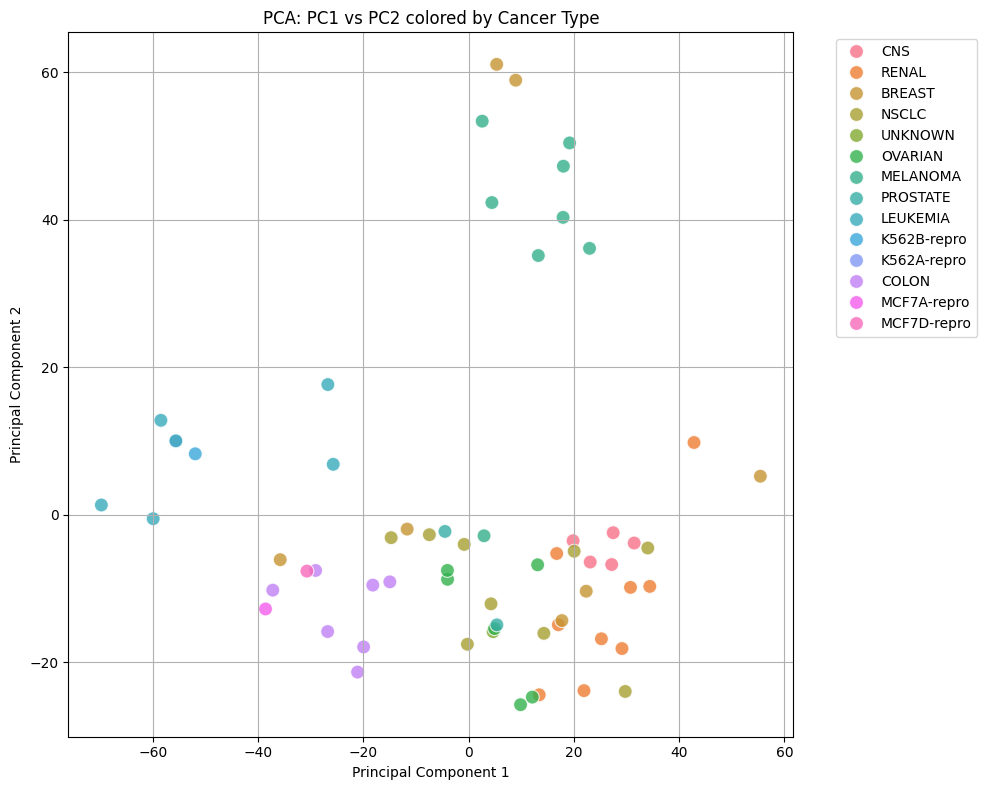

In [8]:
import pandas as pd
import seaborn as sns

# Create a DataFrame for plotting PC1 and PC2 with labels
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'CancerType': nci60_data['labels'].values.flatten()
})

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='CancerType', data=pca_df, s=100, alpha=0.8)
plt.title('PCA: PC1 vs PC2 colored by Cancer Type')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Despite the fact that here clusters seem to be very obvious there we are only looking at 2 out of the around 40+ componentes to have and be abel to get mor ethan 90% of the data and the variance.

### 🔍 Analyzing the Dendrogram

Look at the dendrogram:
- Where are the big jumps in height?
- Do some cell lines cluster together clearly?
- What does this tell us about natural groupings in the data?

## Hierarchical Clustering

Hierarchical clustering is another method for grouping similar data points into clusters. It builds a hierarchy of clusters, represented by a dendrogram. Here, we'll use the `scipy` library to perform hierarchical clustering on the standardized PCA data.

We'll use the `complete` linkage method and `euclidean` distance metric, as requested, to build the dendrogram.

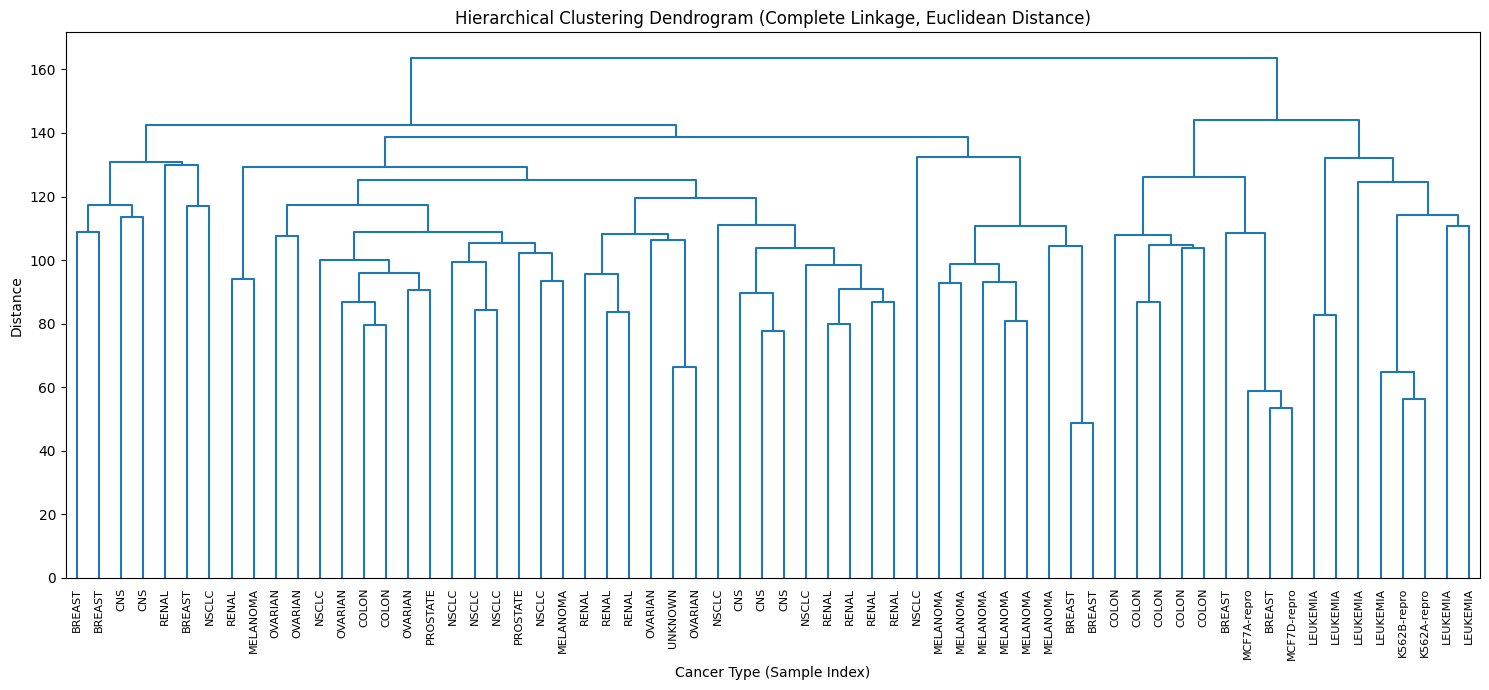

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Calculate the pairwise distances using the 'euclidean' metric
dist_matrix = pdist(X_scaled, metric='euclidean')

# Perform hierarchical clustering using the 'complete' method
hc_clusters = linkage(dist_matrix, method='complete')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
dendrogram(
    hc_clusters,
    labels=nci60_data['labels'].values.flatten(), # Use cancer types as labels
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=0 # Make the dendrogram monochromatic
)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage, Euclidean Distance)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### ✂️ Slicing the Dendrogram into 2 Clusters

In our previous step, we viewed the entire dataset as a single massive cluster (the monochromatic tree). Now, we are making our first horizontal "cut" to separate the data into its **two most fundamental groups**.

**What is happening in the code?**
Instead of blindly guessing a height to cut the tree, we let the math do the work. We located the height of the very last fusion—the "trunk" of the tree—using `hc_clusters[-1, 2]`. This value (**163.49**) is where the final two super-clusters merged. By feeding this exact height into the `color_threshold` parameter, Python automatically assigns distinct colors to the branches below our cut.

Calculated threshold for 2 clusters: 163.49


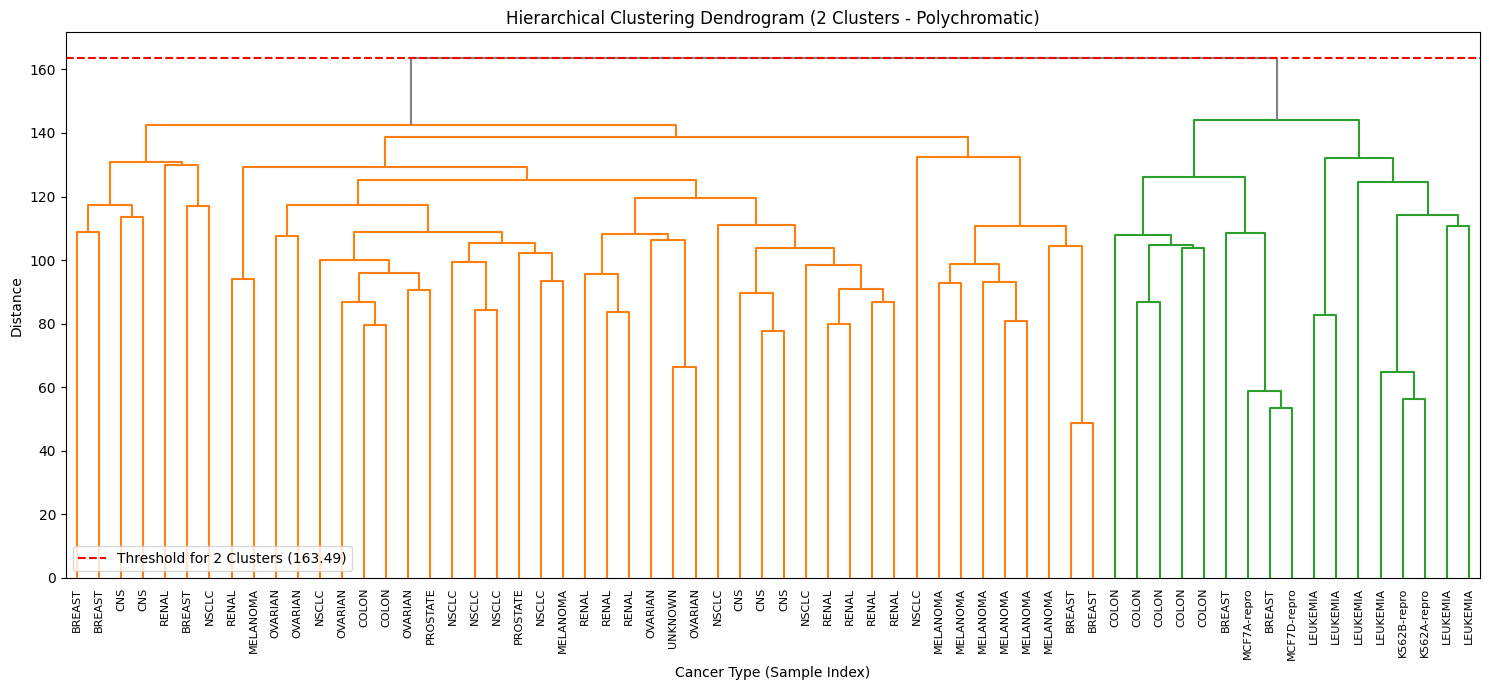

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import numpy as np

# Recalculate if not already available in the current session state
# Calculate the pairwise distances using the 'euclidean' metric
dist_matrix = pdist(X_scaled, metric='euclidean')

# Perform hierarchical clustering using the 'complete' method
hc_clusters = linkage(dist_matrix, method='complete')

# Determine the color threshold for 2 clusters more accurately
# The highest 'distance' value in the linkage matrix (hc_clusters[:, 2]) should roughly correspond to the split into 2 clusters.
# For k clusters, the threshold is hc_clusters[-k+1, 2]. For 2 clusters, it's hc_clusters[-1, 2]
color_threshold_2_clusters_accurate = hc_clusters[-1, 2] # This is the distance at which the last two clusters merge

# Adding a small epsilon for visual clarity of the cut, ensuring the line is above the actual merge point if needed
# However, typically color_threshold in dendrogram function correctly uses the distance itself.
# Let's keep it clean as the exact merge distance is the cut point.

print(f"Calculated threshold for 2 clusters: {color_threshold_2_clusters_accurate:.2f}")

# Plot the dendrogram for 2 clusters with the calculated threshold
plt.figure(figsize=(15, 7))
dendrogram(
    hc_clusters,
    labels=nci60_data['labels'].values.flatten(), # Use cancer types as labels
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=color_threshold_2_clusters_accurate, # Set color threshold for 2 clusters
    above_threshold_color='gray' # Color branches above threshold in gray
)
plt.axhline(y=color_threshold_2_clusters_accurate, color='red', linestyle='--', label=f'Threshold for 2 Clusters ({color_threshold_2_clusters_accurate:.2f})')
plt.title('Hierarchical Clustering Dendrogram (2 Clusters - Polychromatic)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

**What does this graph demonstrate?**
* **The Split:** We have successfully divided the 64 cancer samples into two major groups: the **Orange** cluster (left) and the **Green** cluster (right). 
* **The Biological Insight:** If you look closely at the labels on the x-axis, the Green cluster on the right heavily isolates **LEUKEMIA** samples (along with a few others like Colon). This demonstrates the power of Hierarchical Clustering: without us telling the algorithm anything about the cancer types, it mathematically figured out that Leukemia (a blood cancer) has a fundamentally different gene expression profile than the massive mix of solid tumors (Melanoma, Renal, Ovarian) grouped in the Orange cluster!

### ✂️ Slicing the Dendrogram into 3 Clusters

We are now moving our horizontal cut lower down the tree to reveal a more granular breakdown of our data, creating **three distinct clusters**.

**What changed in the math?**
To find the exact height that produces 3 clusters, we looked at the second-to-last fusion event using `hc_clusters[-2, 2]`. This value (**144.05**) is the precise distance where the green cluster split into two smaller branches. By setting our `color_threshold` just slightly below this mark, Python colors the three resulting branches for us.

Calculated threshold for 3 clusters: 144.05


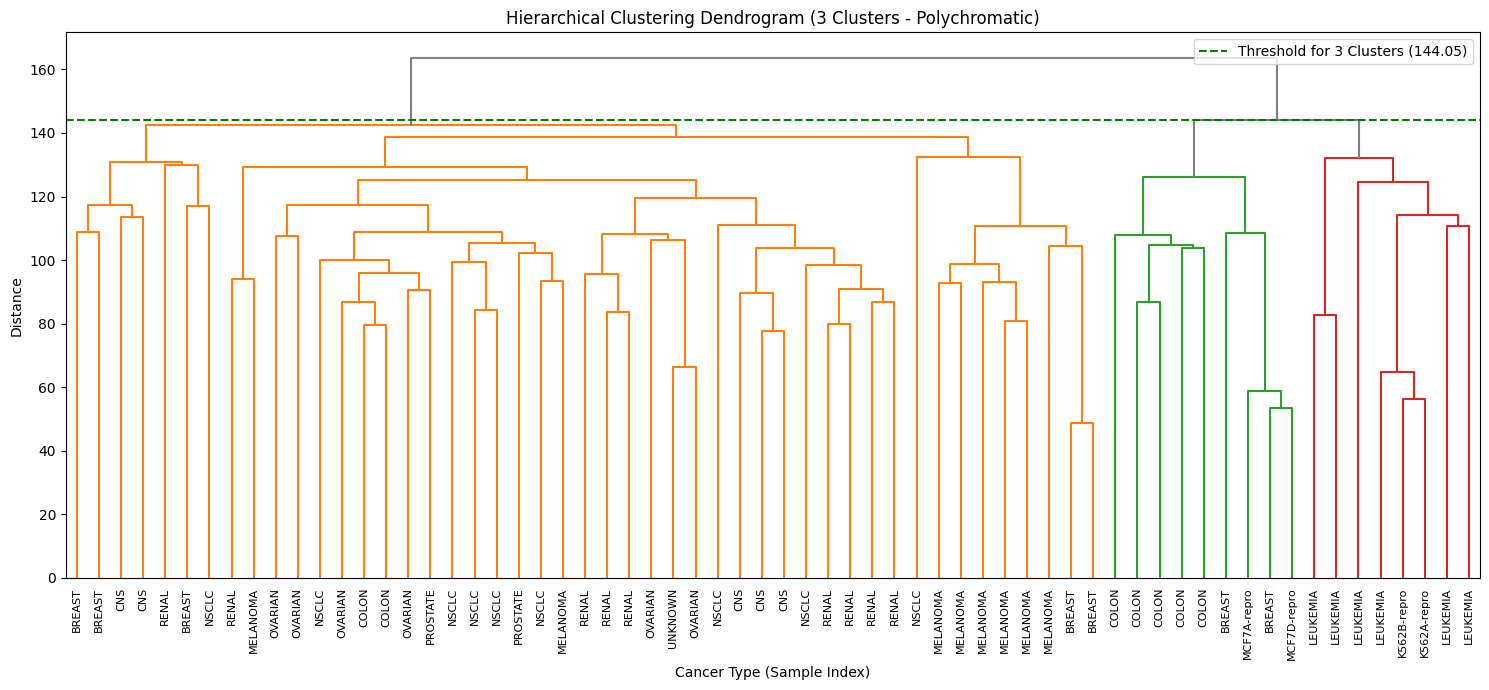

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import numpy as np

# Recalculate if not already available in the current session state
# Calculate the pairwise distances using the 'euclidean' metric
dist_matrix = pdist(X_scaled, metric='euclidean')

# Perform hierarchical clustering using the 'complete' method
hc_clusters = linkage(dist_matrix, method='complete')

# Determine the color threshold for 3 clusters more accurately
# For k clusters, the threshold is hc_clusters[-k+1, 2]. For 3 clusters, it's hc_clusters[-3+1, 2] = hc_clusters[-2, 2]
color_threshold_3_clusters_accurate = hc_clusters[-2, 2] # This is the distance at which the second to last merge happened

print(f"Calculated threshold for 3 clusters: {color_threshold_3_clusters_accurate:.2f}")

# Plot the dendrogram for 3 clusters with the calculated threshold
plt.figure(figsize=(15, 7))
dendrogram(
    hc_clusters,
    labels=nci60_data['labels'].values.flatten(), # Use cancer types as labels
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=color_threshold_3_clusters_accurate, # Set color threshold for 3 clusters
    above_threshold_color='gray' # Color branches above threshold in gray
)
plt.axhline(y=color_threshold_3_clusters_accurate, color='green', linestyle='--', label=f'Threshold for 3 Clusters ({color_threshold_3_clusters_accurate:.2f})')
plt.title('Hierarchical Clustering Dendrogram (3 Clusters - Polychromatic)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

**What does this graph demonstrate?**
* **The "Nested" Property:** Notice the massive Orange cluster on the left? *It is completely untouched.* This perfectly illustrates the "nested" nature of Hierarchical Clustering. When we moved from 2 clusters to 3, the algorithm didn't scramble all the data; it simply took the existing right-side cluster and subdivided it.
* **The Biological Insight:** The original large cluster on the right has now split into two highly specific groups:
    * **The Green Cluster:** Predominantly composed of **COLON** and **BREAST** cancer samples.
    * **The Red Cluster:** Almost exclusively composed of **LEUKEMIA** samples.
* The algorithm has mathematically proven that while Colon, Breast, and Leukemia cancers are somewhat similar to each other (compared to the Orange group).

### ✂️ Slicing the Dendrogram into 4 Clusters

We are making one final cut, lowering our threshold again to segment the data into **four unique clusters**. 

**What changed in the math?**
To achieve exactly 4 clusters, we identified the height of the third-to-last fusion event using `hc_clusters[-3, 2]`. This distance (**142.36**) represents the point where the large orange cluster from our previous steps finally splits in two. 

Calculated threshold for 4 clusters: 142.36


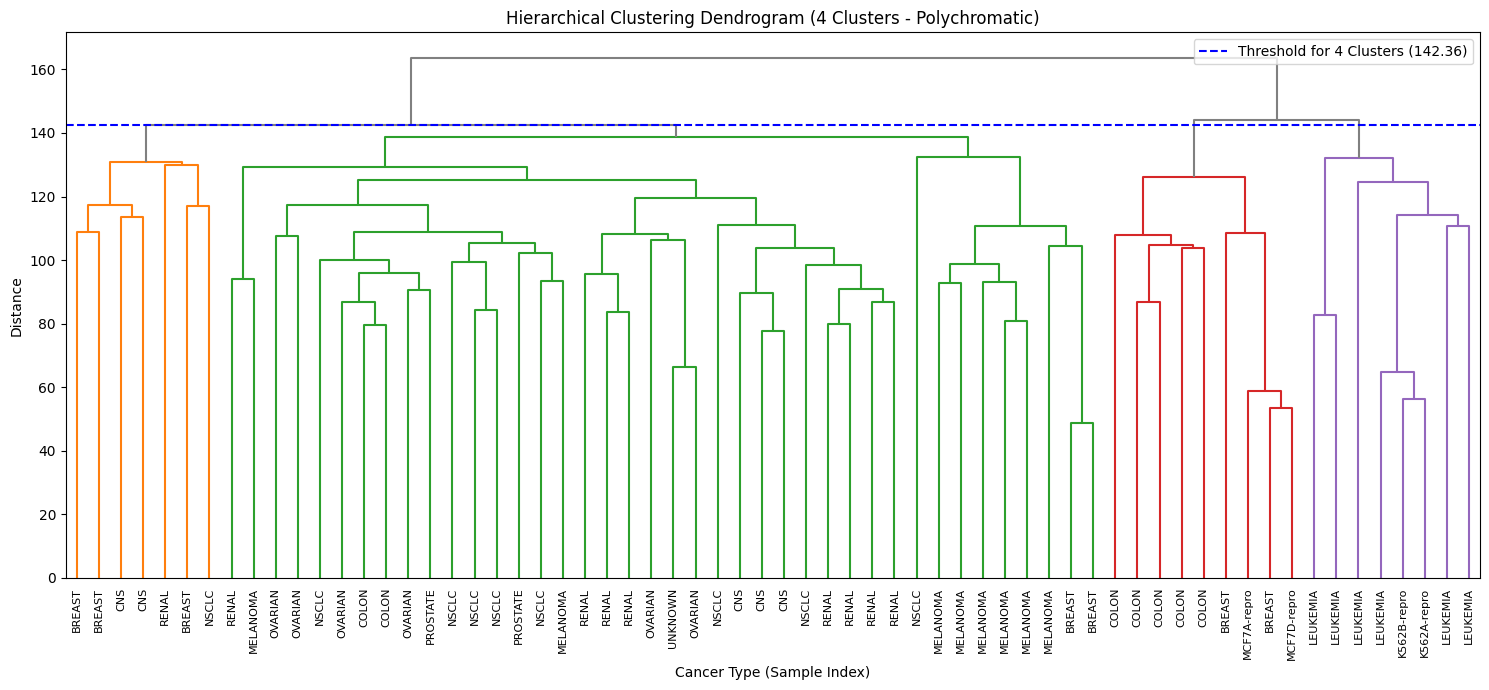

In [20]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import numpy as np

# Recalculate if not already available in the current session state
# Calculate the pairwise distances using the 'euclidean' metric
dist_matrix = pdist(X_scaled, metric='euclidean')

# Perform hierarchical clustering using the 'complete' method
hc_clusters = linkage(dist_matrix, method='complete')

# Determine the color threshold for 4 clusters more accurately
# For k clusters, the threshold is hc_clusters[-k+1, 2]. For 4 clusters, it's hc_clusters[-4+1, 2] = hc_clusters[-3, 2]
color_threshold_4_clusters_accurate = hc_clusters[-3, 2] # This is the distance at which the third to last merge happened

print(f"Calculated threshold for 4 clusters: {color_threshold_4_clusters_accurate:.2f}")

# Plot the dendrogram for 4 clusters with the calculated threshold
plt.figure(figsize=(15, 7))
dendrogram(
    hc_clusters,
    labels=nci60_data['labels'].values.flatten(), # Use cancer types as labels
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=color_threshold_4_clusters_accurate, # Set color threshold for 4 clusters
    above_threshold_color='gray' # Color branches above threshold in gray
)
plt.axhline(y=color_threshold_4_clusters_accurate, color='blue', linestyle='--', label=f'Threshold for 4 Clusters ({color_threshold_4_clusters_accurate:.2f})')
plt.title('Hierarchical Clustering Dendrogram (4 Clusters - Polychromatic)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

**What does this graph demonstrate?**
* **The "Nested" Property (Again):** Lowering the threshold simply caused the massive original left-side cluster to finally subdivide.
* **The Biological Insight:** The original solid tumor group has now split into two sub-groups:
    * **The Orange Cluster:** A smaller, highly specific group containing mostly **BREAST**, **CNS** (Central Nervous System), and some **RENAL** samples.
    * **The Green Cluster:** The remaining bulk of the solid tumors, heavily dominated by **MELANOMA**, **OVARIAN**, and **NSCLC** (Non-Small Cell Lung Cancer).
* This 4-cluster model gives us a highly nuanced view: it separates blood cancers (Leukemia), isolates specific solid tumors (Colon/Breast), and begins to distinguish between different types of broader solid tumors (Melanoma vs. CNS/Renal).

### 🔄 Switching the Metric: Correlation Distance

Up to this point, we used **Euclidean distance**, which groups samples based on the overall *magnitude* (volume) of their gene expression. 

Now, we are changing our metric to **Correlation**. This fundamentally shifts how the algorithm defines similarity. Instead of looking at raw volume, it now groups cancer samples based on their **expression patterns**—specifically looking at whether their gene levels rise and fall together across the dataset, regardless of their absolute scale. 

We will keep the linkage method as `complete` to maintain tight clusters. Let's see how this new mathematical perspective reshapes our tree!

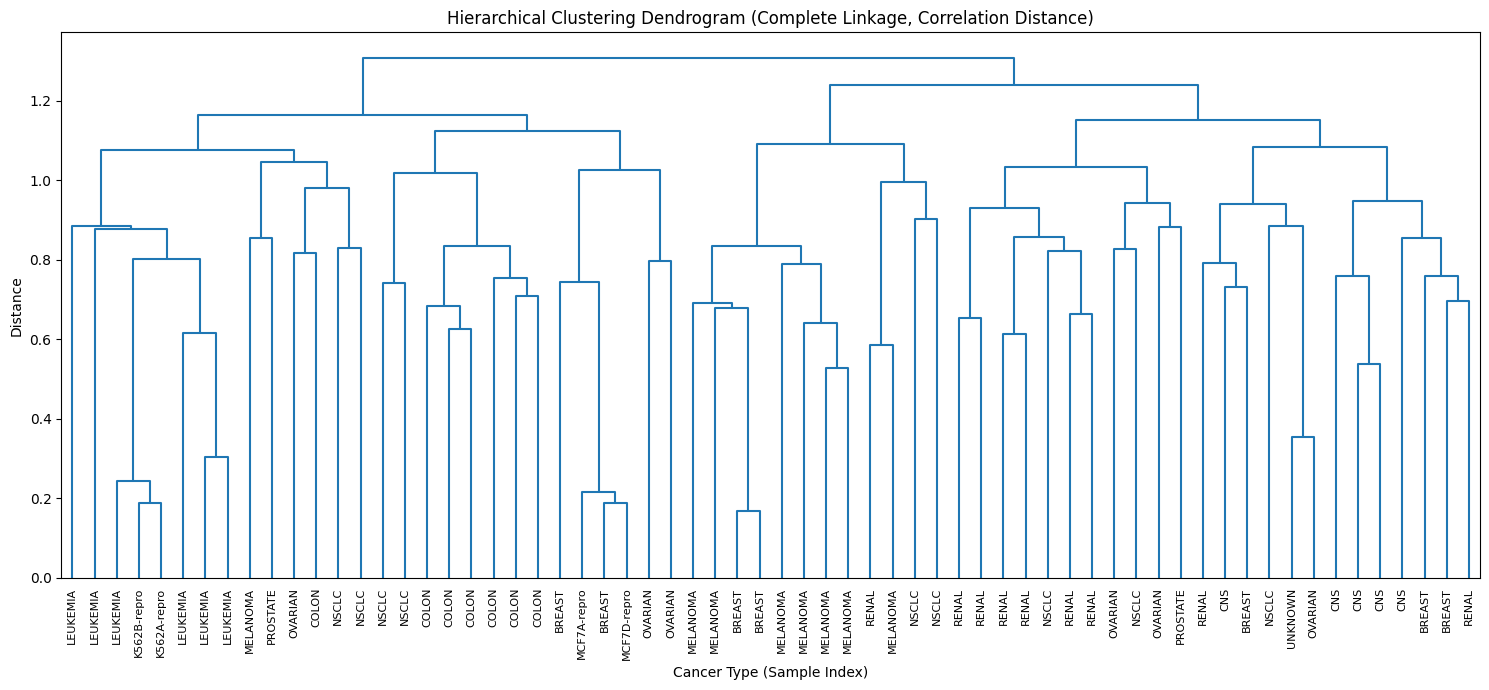

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Calculate the pairwise distances using the 'correlation' metric
dist_matrix_corr = pdist(X_scaled, metric='correlation')

# Perform hierarchical clustering using the 'complete' method
hc_clusters_corr = linkage(dist_matrix_corr, method='complete')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
dendrogram(
    hc_clusters_corr,
    labels=nci60_data['labels'].values.flatten(), # Use cancer types as labels
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=0 # Make the dendrogram polychromatic
)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage, Correlation Distance)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

## Side-by-Side Comparison of Dendrograms

To facilitate comparison, let's plot both the dendrogram using Euclidean distance and the dendrogram using correlation distance side-by-side.

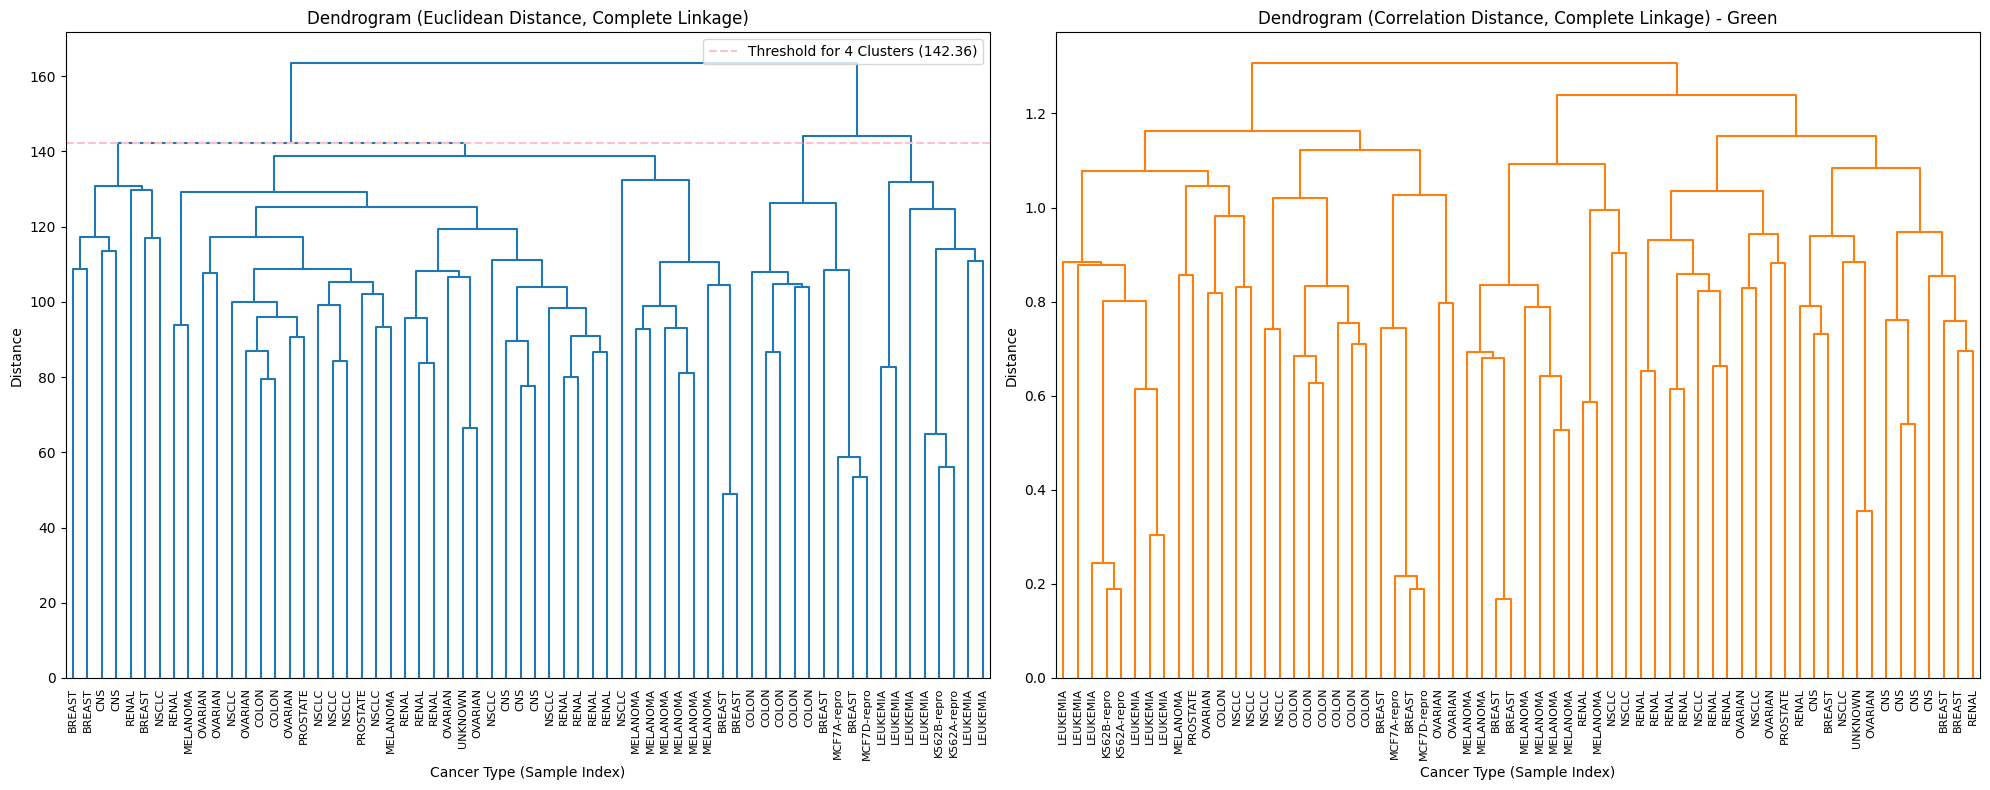

In [27]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import numpy as np

# Ensure hc_clusters and hc_clusters_corr are available from previous executions
# If not, the preceding cells must be re-run.

plt.figure(figsize=(20, 8))

# Subplot 1: Euclidean Distance Dendrogram
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
dendrogram(
    hc_clusters,
    labels=nci60_data['labels'].values.flatten(),
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=0 # Keep as polychromatic with default colors (including blue)
)
plt.axhline(y=color_threshold_4_clusters_accurate, color='pink', linestyle='--', label=f'Threshold for 4 Clusters ({color_threshold_4_clusters_accurate:.2f})')
plt.title('Dendrogram (Euclidean Distance, Complete Linkage)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.legend()

# Subplot 2: Correlation Distance Dendrogram
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
# Calculate a threshold that is higher than any merge distance to make it monochromatic
monochromatic_threshold_corr = np.max(hc_clusters_corr[:, 2]) * 1.05 # A value slightly higher than the max distance
dendrogram(
    hc_clusters_corr,
    labels=nci60_data['labels'].values.flatten(),
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=monochromatic_threshold_corr, # Set high threshold for monochromatic
    above_threshold_color='green' # Color all branches above this (i.e., all) green
)
plt.title('Dendrogram (Correlation Distance, Complete Linkage)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

Left Dendrogram (Euclidean Distance): This one uses Euclidean distance and is displayed with a polychromatic coloring scheme, and it now includes a pink dashed line indicating the threshold for 4 clusters, which we previously calculated to be 142.36.

Right Dendrogram (Correlation Distance): This dendrogram, using correlation distance, is now entirely colored in green, providing a distinct visual contrast to the Euclidean one. This monochromatic green representation emphasizes the overall clustering structure based on gene expression patterns.



### ⚖️ Balancing the Tree: Average Linkage

So far, we have been using *Complete Linkage*, which measures the distance between two clusters by looking only at their absolute *farthest* points. It is a strict, extreme measurement. 

Now, let's switch to **Average Linkage** (while keeping our metric as Euclidean). Instead of looking at extremes, this method calculates the mean distance between *all* points in Cluster A and *all* points in Cluster B. This tends to produce a more mathematically balanced "middle-of-the-road" tree. Let's generate the monochromatic baseline to see how the overall structure shifts!

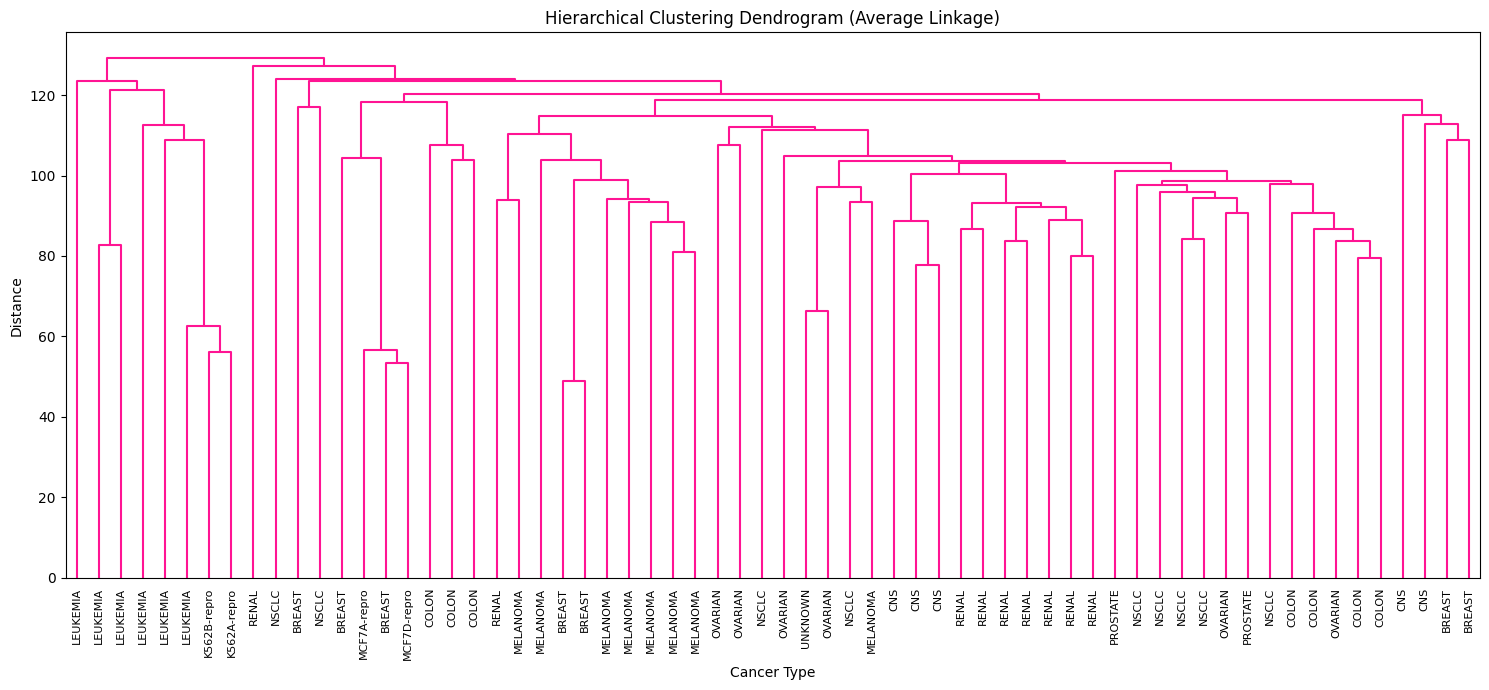

In [31]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

hc_clusters_avg = linkage(X_scaled, method='average', metric='euclidean')

plt.figure(figsize=(15, 7))

# 2. Generate the dendrogram
dendrogram(
    hc_clusters_avg,
    labels=nci60_data['labels'].values.flatten(),
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=0,                # Setting this to 0 forces the entire tree to use the color below
    above_threshold_color='deeppink'  # Your pretty pink!
)

plt.title('Hierarchical Clustering Dendrogram (Average Linkage)')
plt.xlabel('Cancer Type')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Calculated 4-cluster threshold for Correlation (Complete): 1.16
Calculated 4-cluster threshold for Euclidean (Average): 123.94


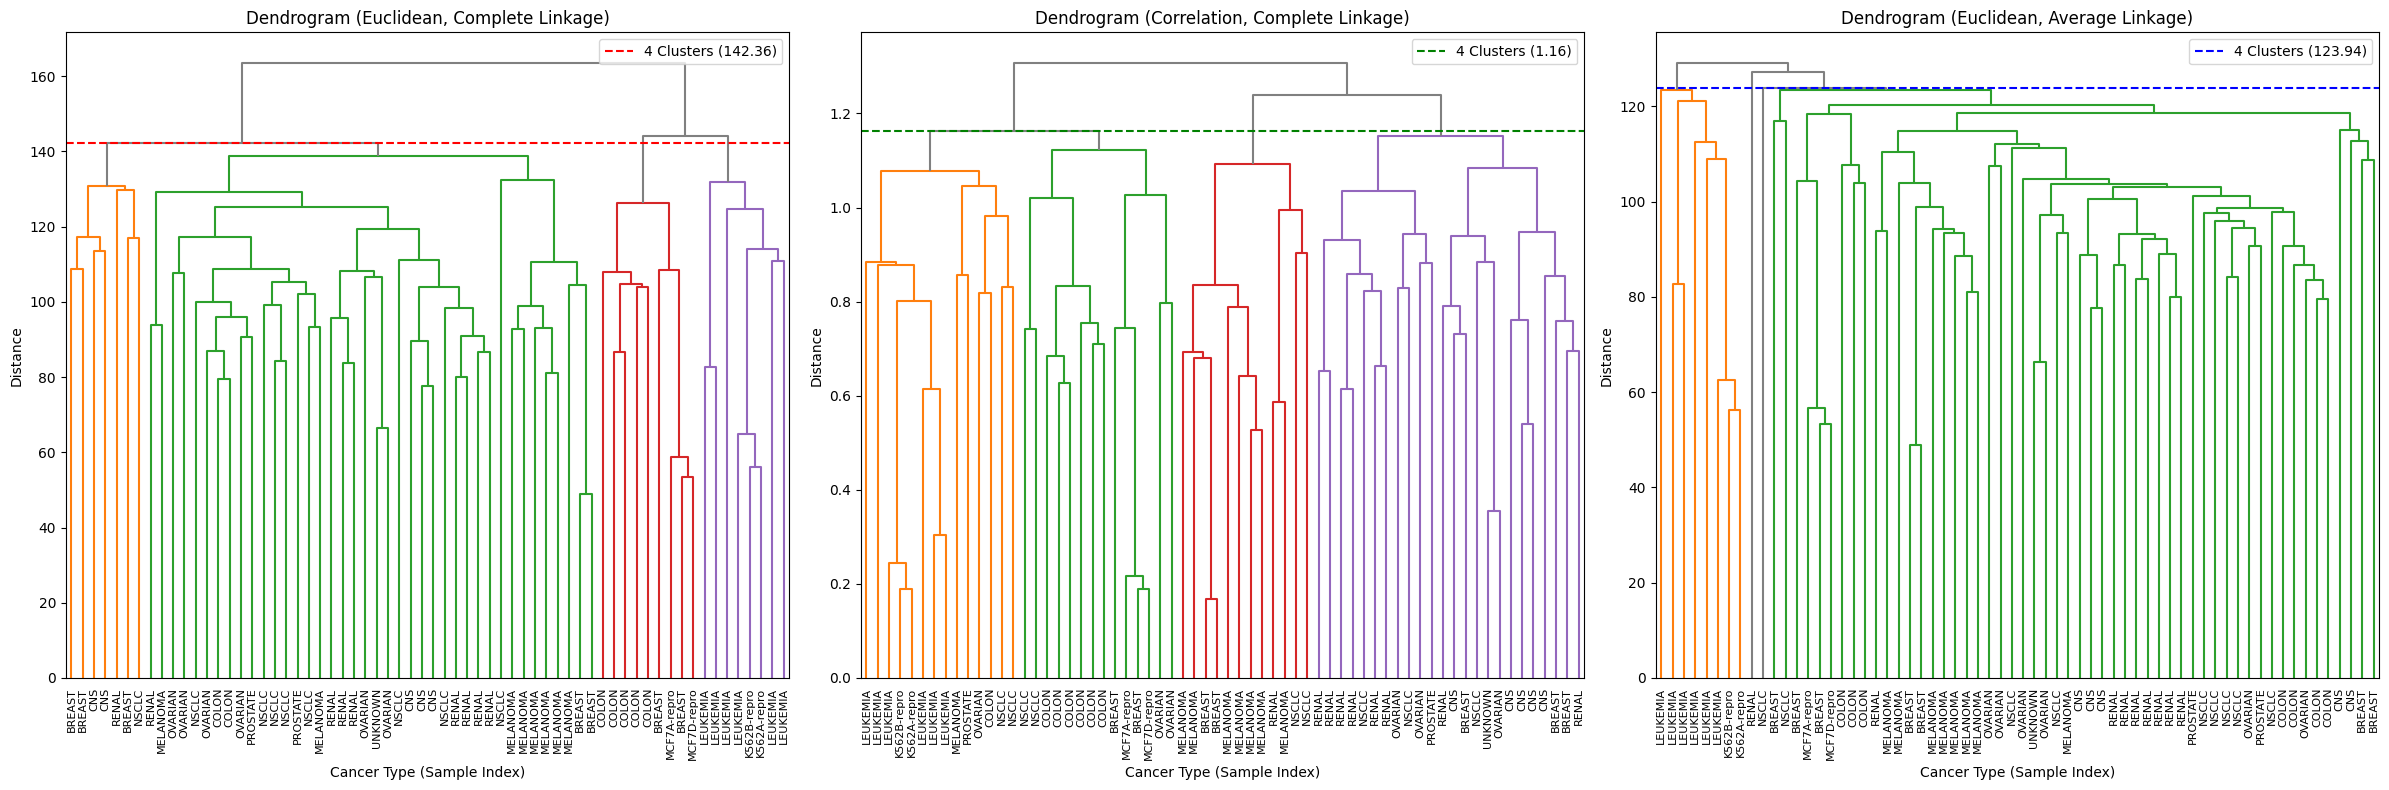

In [34]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, fcluster
import numpy as np

# Ensure all necessary variables are available. If not, re-run previous cells.
# hc_clusters (Euclidean, Complete) and color_threshold_4_clusters_accurate are already defined.
# hc_clusters_corr (Correlation, Complete) is already defined.
# hc_clusters_avg (Euclidean, Average) is already defined.

# Calculate the 4-cluster threshold for Correlation (Complete) dendrogram
corr_threshold_4_clusters = hc_clusters_corr[-3, 2]
print(f"Calculated 4-cluster threshold for Correlation (Complete): {corr_threshold_4_clusters:.2f}")

# Calculate the 4-cluster threshold for Euclidean (Average) dendrogram
avg_threshold_4_clusters = hc_clusters_avg[-3, 2]
print(f"Calculated 4-cluster threshold for Euclidean (Average): {avg_threshold_4_clusters:.2f}")

plt.figure(figsize=(24, 8))

# Subplot 1: Euclidean Distance, Complete Linkage
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
dendrogram(
    hc_clusters,
    labels=nci60_data['labels'].values.flatten(),
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=color_threshold_4_clusters_accurate, # Use previously calculated threshold
    above_threshold_color='gray' # Color branches above threshold in gray
)
plt.axhline(y=color_threshold_4_clusters_accurate, color='red', linestyle='--', label=f'4 Clusters ({color_threshold_4_clusters_accurate:.2f})')
plt.title('Dendrogram (Euclidean, Complete Linkage)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.legend()

# Subplot 2: Correlation Distance, Complete Linkage
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
dendrogram(
    hc_clusters_corr,
    labels=nci60_data['labels'].values.flatten(),
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=corr_threshold_4_clusters, # Use newly calculated threshold
    above_threshold_color='gray' # Color branches above threshold in gray
)
plt.axhline(y=corr_threshold_4_clusters, color='green', linestyle='--', label=f'4 Clusters ({corr_threshold_4_clusters:.2f})')
plt.title('Dendrogram (Correlation, Complete Linkage)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.legend()

# Subplot 3: Euclidean Distance, Average Linkage
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
dendrogram(
    hc_clusters_avg,
    labels=nci60_data['labels'].values.flatten(),
    orientation='top',
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=avg_threshold_4_clusters, # Use newly calculated threshold
    above_threshold_color='gray' # Color branches above threshold in gray
)
plt.axhline(y=avg_threshold_4_clusters, color='blue', linestyle='--', label=f'4 Clusters ({avg_threshold_4_clusters:.2f})')
plt.title('Dendrogram (Euclidean, Average Linkage)')
plt.xlabel('Cancer Type (Sample Index)')
plt.ylabel('Distance')
plt.legend()

plt.tight_layout()
plt.show()

### 🤔 So, Which Method is the "Right" One?

As you have just seen, simply changing a distance metric or a linkage rule completely rewrites the shape of the tree. So which one should you use? The Data Science answer is: **It depends entirely on your objective.**

Here is a quick cheat sheet for the real world:
* **Complete Linkage:** Use this when you want tight, highly distinct clusters (it resists outliers well).
* **Average Linkage:** Use this for a balanced, compromise approach when Complete Linkage feels too strict.
* **Ward Linkage:** Highly recommended for pure numerical data when using Euclidean distance; it actively tries to minimize variance inside the clusters.
* **The Golden Rule:** Clustering is exploratory. Try several combinations, and pick the one that reveals groups that actually make **biological or business sense**!

---

## 🎓 Key Concepts from Hierarchical Clustering

### What You've Learned:
1. **Dendrograms** - Visual representation of hierarchical clustering
2. **Linkage methods** - Different ways to measure distance between groups (single, complete, average, Ward)
3. **Agglomerative vs Divisive** - Bottom-up vs top-down clustering
4. **No K needed** - You choose K by cutting the tree
5. **Interpretability** - The dendrogram shows the entire clustering process

---

## 🚀 Further Learning & Key Concepts

### Next Clustering Algorithms:
- **DBSCAN** - Finds clusters of any shape, doesn't need K
- **Gaussian Mixture Models** - Probabilistic clustering
- **Spectral Clustering** - Good for non-convex clusters

### Practical Skills:
- Try hierarchical clustering on your own dataset
- Compare dendrograms from different linkage methods
- Combine with PCA for high-dimensional data
- Use silhouette analysis to validate clusters

**Remember**: The best clustering method depends on YOUR data and YOUR question. Always visualize and validate your results! 📊